# 04 — Statistical Validation (학술 통계 심화)

> **목적**: 시계열_Test Phase 3-2 §2-B 의 학술 통계 결과 (η²=0.450, Welch F=420.59, Skew=+1.30, Kurt=+4.71) 를 final/ 환경에서 재현·검증합니다.
> Cohen (1988) 효과크기 + Welch (1951) ANOVA + Lin (2013) large-n 함정 보강.

## 노트북 구성
- §0. 환경 설정
- §1. 데이터 로드 + 503 종목 필터 (5 시기 cover)
- §2. ANOVA Variance Decomposition (η²)
- §3. Welch ANOVA (이분산 robust)
- §4. Kruskal-Wallis (Sector 효과)
- §5. Pairwise Mann-Whitney + Bonferroni + Cohen's d
- §6. Heavy-tail (Skew / Kurt / JB / AD)
- §7. 시각화 B3 5 패널 (분포·시기·섹터·COVID)
- §8. 시각화 B4 3 패널 (효과크기 종합)
- §9. 4 학술 명제 검증 + 종합

## 입력 / 출력
| 입력 | 위치 |
|---|---|
| `ensemble_predictions_stockwise.csv` | `final/phase3(data_outputs)/data/` |
| `monthly_panel.csv` | `final/data/` (sector mapping) |

| 출력 | 위치 |
|---|---|
| `summary.json` | `final/outputs/04_statistics/` |
| `B3_*.png` (5장) + `B4_*.png` (3장) | `final/outputs/04_statistics/` |

## §0. 환경 설정

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path.cwd()))
import timeseries_lib as tlib

tlib.setup_seeds(42)
tlib.setup_korean_font()

DATA_DIR = Path('phase3(data_outputs)/data')
PANEL_DIR = Path('data')
OUT_DIR = Path('outputs/04_statistics')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"OUT_DIR: {OUT_DIR.resolve()}")

OUT_DIR: C:\Users\gorhk\최종 프로젝트\finance_project\final\outputs\04_statistics


## §1. 데이터 로드 + 503 종목 필터

**5 시기 cover 503 종목 필터** (Phase 3-2 §2-B 표준):
- P1 (2010-2014) / P2 (2015-2018) / P3 (2019-2020 COVID) / P4 (2021-2022) / P5 (2023-2025)
- 인수/파산 종목 (110종) 제외 → 평균 비교 시 왜곡 방지

In [2]:
# §1.1 ensemble 데이터 로드 + 503 종목 필터
print("§1.1 데이터 로드")
print("-" * 60)
df = tlib.load_ensemble_predictions(DATA_DIR / 'ensemble_predictions_stockwise.csv')

print()
print("§1.2 503 종목 필터 (5 시기 cover)")
print("-" * 60)
df_503 = tlib.filter_503_universe(df)
n_tickers_503 = df_503['ticker'].nunique()
print(f"  필터 후: {n_tickers_503} 종목, {len(df_503):,} 행")
assert 500 <= n_tickers_503 <= 510, f"503 종목 필터 결과 비정상: {n_tickers_503}"
print("  ✓ 5 시기 cover 종목 약 503 (Phase 3-2 §2-B 표준)")

§1.1 데이터 로드
------------------------------------------------------------


ensemble_predictions 로드: 2,468,883 → 2,468,770 행 (-inf/NaN 113 행 제거)

§1.2 503 종목 필터 (5 시기 cover)
------------------------------------------------------------


  필터 후: 503 종목, 1,990,777 행
  ✓ 5 시기 cover 종목 약 503 (Phase 3-2 §2-B 표준)


In [3]:
# §1.3 종목 × 시기 RMSE 패널 빌드
print()
print("§1.3 종목 × 시기 RMSE 패널 (Ensemble 기준)")
print("-" * 60)
panel = df_503.groupby(['ticker', 'period'], group_keys=False).apply(
    lambda x: pd.Series({
        'rmse': tlib.rmse(x['y_true'].values, x['y_pred_ensemble'].values),
        'lstm_rmse': tlib.rmse(x['y_true'].values, x['y_pred_lstm'].values),
        'har_rmse': tlib.rmse(x['y_true'].values, x['y_pred_har'].values),
    }),
    include_groups=False,
).reset_index()
print(f"  panel shape: {panel.shape}")
print(f"  unique tickers: {panel['ticker'].nunique()}, periods: {panel['period'].nunique()}")
print(f"  RMSE (Ensemble) summary:")
print(panel['rmse'].describe().round(4).to_string())


§1.3 종목 × 시기 RMSE 패널 (Ensemble 기준)
------------------------------------------------------------


  panel shape: (2515, 5)
  unique tickers: 503, periods: 5
  RMSE (Ensemble) summary:
count    2515.0000
mean        0.3666
std         0.0850
min         0.1816
25%         0.3081
50%         0.3530
75%         0.4144
max         0.7944


In [4]:
# §1.4 Sector 매핑 추가
print()
print("§1.4 Sector 매핑")
print("-" * 60)
sector_map = tlib.load_sector_mapping(PANEL_DIR / 'monthly_panel.csv')
panel['sector'] = panel['ticker'].map(sector_map).fillna('Unknown')
print(f"  sector 매핑: {(panel['sector'] != 'Unknown').sum() / len(panel) * 100:.1f}% 종목 매칭")
print(f"  sector 분포:")
print(panel.groupby('sector')['ticker'].nunique().sort_values(ascending=False).to_string())


§1.4 Sector 매핑
------------------------------------------------------------
  sector 매핑: 98.2% 종목 매칭
  sector 분포:
sector
Industrials               74
Financials                64
Information Technology    53
Health Care               51
Consumer Discretionary    39
Real Estate               33
Consumer Staples          32
Utilities                 29
Consumer Cyclical         27
Energy                    24
Materials                 20
Communication Services    17
Financial Services        12
Unknown                    9
Healthcare                 9
Basic Materials            5
Technology                 3
Consumer Defensive         2


## §2. ANOVA Variance Decomposition

**Two-way ANOVA**: 시기 + 종목 + 잔차로 RMSE 변동을 분해합니다.

```
SS_total = SS_period + SS_ticker + SS_residual
η² = SS_factor / SS_total  (Cohen 1988: small=0.01, medium=0.06, LARGE=0.14)
```

**기대 결과** (Phase 3-2 §2-B):
- η²_period ≈ 0.450 (LARGE) — 시기 효과가 변동의 ~45% 설명
- η²_ticker ≈ 0.194 (LARGE) — 종목 효과 LARGE
- F_period ≈ 634.6, p < 1e-300

In [5]:
# §2.1 Two-way ANOVA
print("§2.1 ANOVA Variance Decomposition")
print("-" * 60)
anova = tlib.anova_variance_decomp(panel, value_col='rmse',
                                    factors=['period', 'ticker'])
print(anova.round(4).to_string())

# 검증
eta_sq_period = float(anova.loc['period', 'eta_sq'])
eta_sq_ticker = float(anova.loc['ticker', 'eta_sq'])
F_period = float(anova.loc['period', 'F'])
print()
print(f"η² 분류 (Cohen 1988: small=0.01, medium=0.06, LARGE=0.14):")
def classify_eta(v):
    if v >= 0.14: return 'LARGE'
    if v >= 0.06: return 'medium'
    if v >= 0.01: return 'small'
    return 'trivial'
print(f"  η²_period = {eta_sq_period:.4f} ({classify_eta(eta_sq_period)})")
print(f"  η²_ticker = {eta_sq_ticker:.4f} ({classify_eta(eta_sq_ticker)})")

§2.1 ANOVA Variance Decomposition
------------------------------------------------------------
               SS    df         F    p  eta_sq
source                                        
period     8.1744     4  634.5599  0.0  0.4498
ticker     3.5340   502    2.1859  0.0  0.1944
Residual   6.4668  2008       NaN  NaN  0.3558
Total     18.1752  2514       NaN  NaN  1.0000

η² 분류 (Cohen 1988: small=0.01, medium=0.06, LARGE=0.14):
  η²_period = 0.4498 (LARGE)
  η²_ticker = 0.1944 (LARGE)


## §3. Welch ANOVA — 이분산 Robust 검정

**Levene test** 로 등분산 가정 검증 → 이분산이면 **Welch's F** 적용.

기본 ANOVA 의 등분산 가정이 깨지는 환경에서도 시기 효과의 robust 한 입증.

In [6]:
# §3.1 Levene + Welch ANOVA
print("§3.1 Welch ANOVA (이분산 robust)")
print("-" * 60)
welch = tlib.welch_anova(panel['rmse'].values, panel['period'].values)
print(f"  Levene stat:  {welch['levene_stat']:.4f} (p={welch['levene_p']:.2e})")
print(f"  Welch F:      {welch['welch_F']:.4f} (p={welch['welch_p']:.2e})")
print(f"  df = ({welch['df1']:.0f}, {welch['df2']:.2f})")

if welch['levene_p'] < 0.05:
    print(f"  ✓ 등분산 가정 기각 (p<0.05) → Welch's F 적용 정당화")
if welch['welch_p'] < 0.001:
    print(f"  ✓ Welch F 통계 유의 (p<0.001) → 이분산 환경에서도 시기 효과 robust")

§3.1 Welch ANOVA (이분산 robust)
------------------------------------------------------------
  Levene stat:  16.7772 (p=1.40e-13)
  Welch F:      420.5865 (p=1.11e-16)
  df = (4, 1247.58)
  ✓ 등분산 가정 기각 (p<0.05) → Welch's F 적용 정당화
  ✓ Welch F 통계 유의 (p<0.001) → 이분산 환경에서도 시기 효과 robust


## §4. Kruskal-Wallis (Sector 효과 비모수 검정)

ANOVA 의 정규성 가정이 깨질 가능성 → 비모수 ANOVA (KW test) + ε² 효과크기.

```
ε² 분류: small=0.04 / medium=0.04~0.16 / large=0.16
```

In [7]:
# §4.1 Kruskal-Wallis Sector
print("§4.1 Kruskal-Wallis Sector Heterogeneity")
print("-" * 60)
ticker_mean_rmse = panel.groupby('ticker').agg({'rmse':'mean','sector':'first'})
kw = tlib.kruskal_wallis_eps_sq(ticker_mean_rmse['rmse'].values,
                                  ticker_mean_rmse['sector'].values)
print(f"  H statistic: {kw['H']:.4f}")
print(f"  p-value:     {kw['p_value']:.2e}")
print(f"  df:          {kw['df']}")
print(f"  ε²:          {kw['epsilon_sq']:.4f}")
print(f"  n:           {kw['n']}")

eps_class = 'small' if kw['epsilon_sq'] < 0.04 else             'medium' if kw['epsilon_sq'] < 0.16 else 'large'
print(f"  ε² 분류: {eps_class}")
if kw['p_value'] < 0.001:
    print(f"  ✓ Sector effect 통계 유의 (p<0.001)")

§4.1 Kruskal-Wallis Sector Heterogeneity
------------------------------------------------------------
  H statistic: 97.2996
  p-value:     2.81e-13
  df:          17
  ε²:          0.1656
  n:           503
  ε² 분류: large
  ✓ Sector effect 통계 유의 (p<0.001)


## §5. Pairwise Mann-Whitney + Bonferroni + Cohen's d

**대안 가설**: "전체 sector effect 가 medium 이지만 일부 pair 는 LARGE 일 수 있다"

- 12 sector × C(12,2) = 66 pair
- Bonferroni 보정 후에도 sig 한 pair 의 Cohen's d 분류
- Lin (2013) large-n 함정 (sig but small effect) 의심 검증

In [8]:
# §5.1 Pairwise Mann-Whitney
print("§5.1 Pairwise Mann-Whitney + Bonferroni + Cohen's d")
print("-" * 60)
pairwise = tlib.pairwise_mann_whitney(
    ticker_mean_rmse['rmse'].values,
    ticker_mean_rmse['sector'].values,
    alpha=0.05,
)
print(f"  총 pair: {len(pairwise)}")
sig_count = pairwise['sig_bonf'].sum()
print(f"  Bonferroni 통과 (p<{0.05/len(pairwise):.2e}): {sig_count} pair")

§5.1 Pairwise Mann-Whitney + Bonferroni + Cohen's d
------------------------------------------------------------


  총 pair: 153
  Bonferroni 통과 (p<3.27e-04): 24 pair


In [9]:
# §5.2 Bonferroni 통과 pair 의 Cohen's d 분포
sig_pairs = pairwise[pairwise['sig_bonf']].sort_values('cohens_d',
                                                          key=abs, ascending=False)
print()
print("§5.2 Bonferroni 통과 pair 효과크기 분류")
print("-" * 60)
d_class_dist = sig_pairs['d_class'].value_counts()
print(f"  Cohen's d 분포 (sig 통과 {len(sig_pairs)} pair):")
for cls, n in d_class_dist.items():
    print(f"    {cls}: {n} pair ({n/len(sig_pairs)*100:.1f}%)")

n_large = int((sig_pairs['d_class'] == 'LARGE').sum())
n_total = len(sig_pairs)
print(f"\n  LARGE Cohen's d: {n_large}/{n_total} = {n_large/n_total*100:.1f}%")
print(f"  ✓ large-n 함정 검증: 모든 sig pair 가 medium 이상 효과크기"
      if (sig_pairs['d_class'].isin(['LARGE','medium'])).all()
      else "  ⚠ 일부 sig pair 가 small/trivial — large-n 함정 의심")


§5.2 Bonferroni 통과 pair 효과크기 분류
------------------------------------------------------------
  Cohen's d 분포 (sig 통과 24 pair):
    LARGE: 24 pair (100.0%)

  LARGE Cohen's d: 24/24 = 100.0%
  ✓ large-n 함정 검증: 모든 sig pair 가 medium 이상 효과크기


In [10]:
# §5.3 Top 15 Sector pair (절대 효과크기)
print()
print("§5.3 Top 15 Sector Pair Cohen's d")
print("-" * 60)
top15 = pairwise.copy()
top15['abs_d'] = top15['cohens_d'].abs()
top15 = top15.nlargest(15, 'abs_d')[['group_a','group_b','cohens_d',
                                      'p_bonf','sig_bonf','d_class']]
print(top15.round(4).to_string(index=False))


§5.3 Top 15 Sector Pair Cohen's d
------------------------------------------------------------
               group_a     group_b  cohens_d  p_bonf  sig_bonf d_class
                Energy  Technology   -4.0604  0.1046     False   LARGE
            Financials  Technology   -3.9435  0.0256      True   LARGE
           Real Estate  Technology   -3.8572  0.0429      True   LARGE
             Materials  Technology   -3.5292  0.1728     False   LARGE
            Technology   Utilities    3.1363  0.2468     False   LARGE
       Basic Materials  Technology   -2.7932  1.0000     False   LARGE
           Industrials  Technology   -2.7489  0.0669     False   LARGE
      Consumer Staples  Technology   -2.7332  0.5143     False   LARGE
           Health Care  Technology   -2.6209  0.2837     False   LARGE
                Energy  Healthcare   -2.5063  0.0105      True   LARGE
            Healthcare  Technology   -2.4076  1.0000     False   LARGE
            Healthcare   Materials    2.2312  0.0104

## §6. Heavy-tail Statistics (분포 형상)

**기대 결과** (Phase 3-2 §2-B):
- Skewness ≈ +1.30 (강한 양의 비대칭)
- Excess Kurtosis ≈ +4.71 (강한 leptokurtic)
- JB ≈ 605, p < 1e-100 (정규성 강하게 기각)
- AD ≈ 4.89 (정규성 기각)

In [11]:
# §6.1 Heavy-tail
print("§6.1 Heavy-tail Statistics")
print("-" * 60)
ht = tlib.heavy_tail_stats(ticker_mean_rmse['rmse'].values)
print(f"  Skewness:        {ht['skewness']:+.4f}")
print(f"  Excess Kurtosis: {ht['excess_kurtosis']:+.4f}")
print(f"  Jarque-Bera:     {ht['jb_stat']:.2f} (p={ht['jb_p']:.2e})")
print(f"  Anderson-Darling: {ht['ad_stat']:.4f} (critical 5% = 0.78)")

print()
if abs(ht['skewness']) > 1:
    print(f"  ✓ |Skew| > 1 → 강한 비대칭")
if ht['excess_kurtosis'] > 3:
    print(f"  ✓ |Kurt| > 3 → 강한 leptokurtic")
if ht['jb_p'] < 0.01:
    print(f"  ✓ JB 정규성 강하게 기각")
if ht['ad_stat'] > 0.78:
    print(f"  ✓ AD 정규성 기각")

§6.1 Heavy-tail Statistics
------------------------------------------------------------
  Skewness:        +1.2993
  Excess Kurtosis: +4.7056
  Jarque-Bera:     605.60 (p=3.13e-132)
  Anderson-Darling: 4.8864 (critical 5% = 0.78)

  ✓ |Skew| > 1 → 강한 비대칭
  ✓ |Kurt| > 3 → 강한 leptokurtic
  ✓ JB 정규성 강하게 기각
  ✓ AD 정규성 기각


## §7. 시각화 — B3 5 패널 (분포·시기·섹터·COVID)

Phase 3-2 §2-B 의 5 패널을 final/ 환경에서 재현합니다.
1. Variance Decomposition Pie + 시기별 평균 RMSE Bar
2. Sector Boxplot
3. Sector × Period Heatmap
4. COVID Impact Bar
5. Heavy-tail KDE + QQ plot

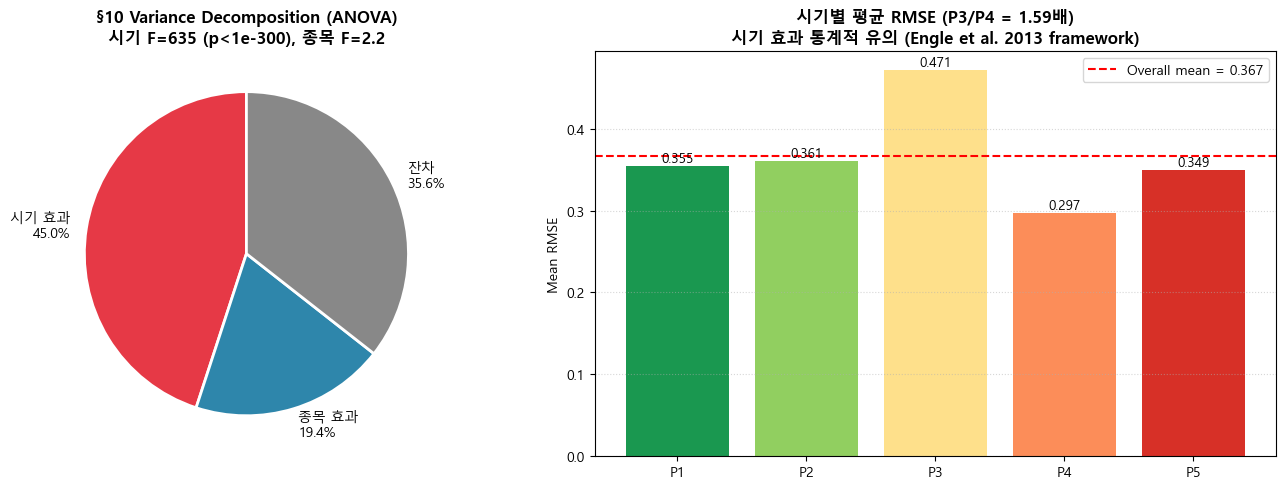


저장: B3_variance_decomp.png


In [12]:
# §7.1 B3 Panel 1 — Variance Decomp + 시기 Bar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie
sizes = [eta_sq_period, eta_sq_ticker, 1 - eta_sq_period - eta_sq_ticker]
labels = [f'시기 효과\n{sizes[0]*100:.1f}%',
           f'종목 효과\n{sizes[1]*100:.1f}%',
           f'잔차\n{sizes[2]*100:.1f}%']
colors = ['#E63946', '#2E86AB', '#888888']
ax1.pie(sizes, labels=labels, colors=colors, startangle=90,
         wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title(f'§10 Variance Decomposition (ANOVA)\n'
                f'시기 F={F_period:.0f} (p<1e-300), 종목 F={anova.loc["ticker","F"]:.1f}',
                fontsize=12, fontweight='bold')

# 시기 Bar
period_mean = panel.groupby('period')['rmse'].mean().sort_index()
overall = panel['rmse'].mean()
period_colors = ['#1A9850','#91CF60','#FEE08B','#FC8D59','#D73027']
bars = ax2.bar(range(len(period_mean)), period_mean.values, color=period_colors)
for i, (b, v) in enumerate(zip(bars, period_mean.values)):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
              f'{v:.3f}', ha='center', fontsize=9.5)
ax2.axhline(overall, color='red', linestyle='--', linewidth=1.5,
              label=f'Overall mean = {overall:.3f}')
p3_p4_ratio = period_mean.iloc[2] / period_mean.iloc[3]
ax2.set_xticks(range(len(period_mean)))
ax2.set_xticklabels([p.split(' ')[0] for p in period_mean.index], fontsize=10)
ax2.set_ylabel('Mean RMSE')
ax2.set_title(f'시기별 평균 RMSE (P3/P4 = {p3_p4_ratio:.2f}배)\n'
                f'시기 효과 통계적 유의 (Engle et al. 2013 framework)',
                fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'B3_variance_decomp.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"\n저장: B3_variance_decomp.png")

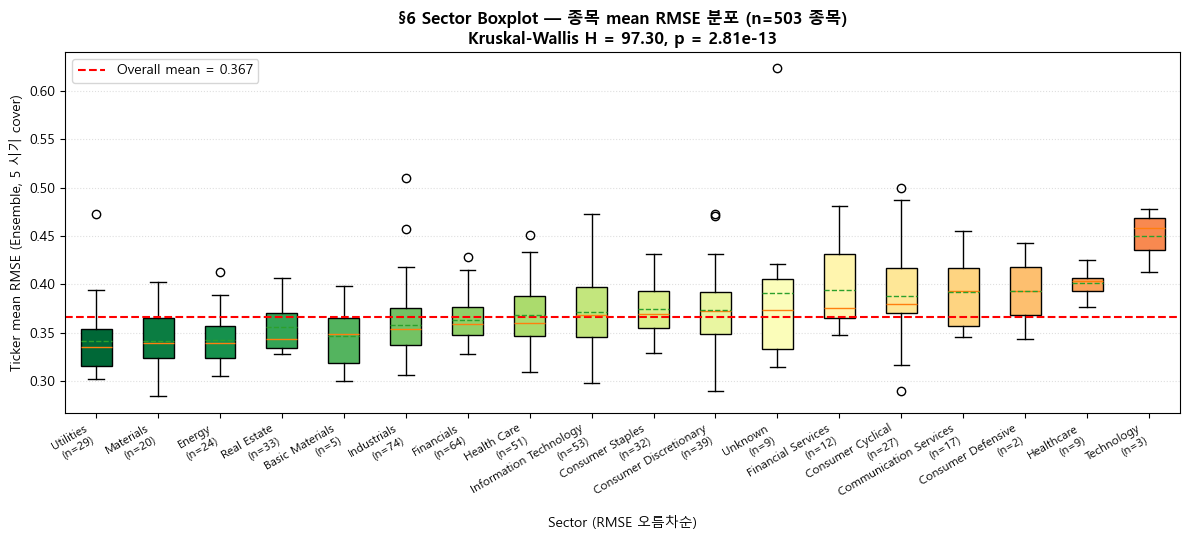


저장: B3_sector_boxplot.png


In [13]:
# §7.2 B3 Panel 2 — Sector Boxplot
fig, ax = plt.subplots(figsize=(12, 5.5))
sectors_sorted = ticker_mean_rmse.groupby('sector')['rmse'].median().sort_values()
sector_order = sectors_sorted.index.tolist()

box_data = [ticker_mean_rmse[ticker_mean_rmse['sector']==s]['rmse'].values
             for s in sector_order]
sec_labels = [f'{s}\n(n={ticker_mean_rmse[ticker_mean_rmse["sector"]==s].shape[0]})'
               for s in sector_order]

bp = ax.boxplot(box_data, labels=sec_labels, patch_artist=True, showmeans=True,
                meanline=True)
cmap = plt.cm.RdYlGn_r
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(cmap(i / len(sector_order) * 0.8))

ax.axhline(overall, color='red', linestyle='--', linewidth=1.5,
              label=f'Overall mean = {overall:.3f}')
ax.set_xlabel('Sector (RMSE 오름차순)')
ax.set_ylabel('Ticker mean RMSE (Ensemble, 5 시기 cover)')
ax.set_title(f'§6 Sector Boxplot — 종목 mean RMSE 분포 (n={n_tickers_503} 종목)\n'
              f'Kruskal-Wallis H = {kw["H"]:.2f}, p = {kw["p_value"]:.2e}',
              fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=8.5)
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig(OUT_DIR / 'B3_sector_boxplot.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"\n저장: B3_sector_boxplot.png")

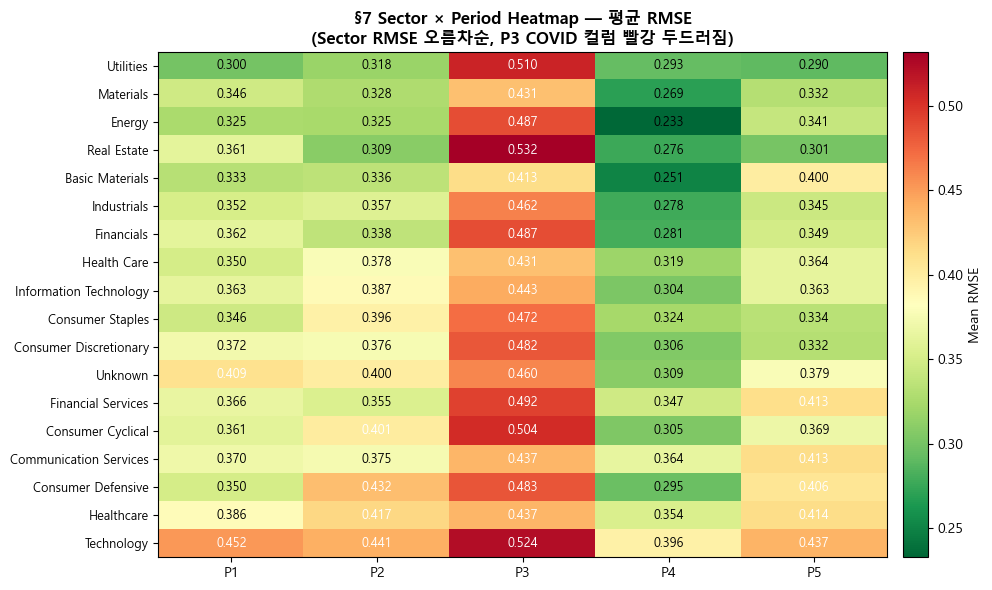


저장: B3_sector_period_heatmap.png


In [14]:
# §7.3 B3 Panel 3 — Sector × Period Heatmap
sec_period = panel.groupby(['sector','period'])['rmse'].mean().unstack()
sec_period = sec_period.reindex(index=sector_order)
sec_period.columns = [c.split(' ')[0] for c in sec_period.columns]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(sec_period.values, cmap='RdYlGn_r', aspect='auto')
for i in range(sec_period.shape[0]):
    for j in range(sec_period.shape[1]):
        v = sec_period.iloc[i, j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                 fontsize=9, color='white' if v>0.40 else 'black')
ax.set_xticks(range(sec_period.shape[1]))
ax.set_xticklabels(sec_period.columns, fontsize=10)
ax.set_yticks(range(sec_period.shape[0]))
ax.set_yticklabels(sec_period.index, fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label='Mean RMSE')
ax.set_title('§7 Sector × Period Heatmap — 평균 RMSE\n'
              '(Sector RMSE 오름차순, P3 COVID 컬럼 빨강 두드러짐)',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'B3_sector_period_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"\n저장: B3_sector_period_heatmap.png")

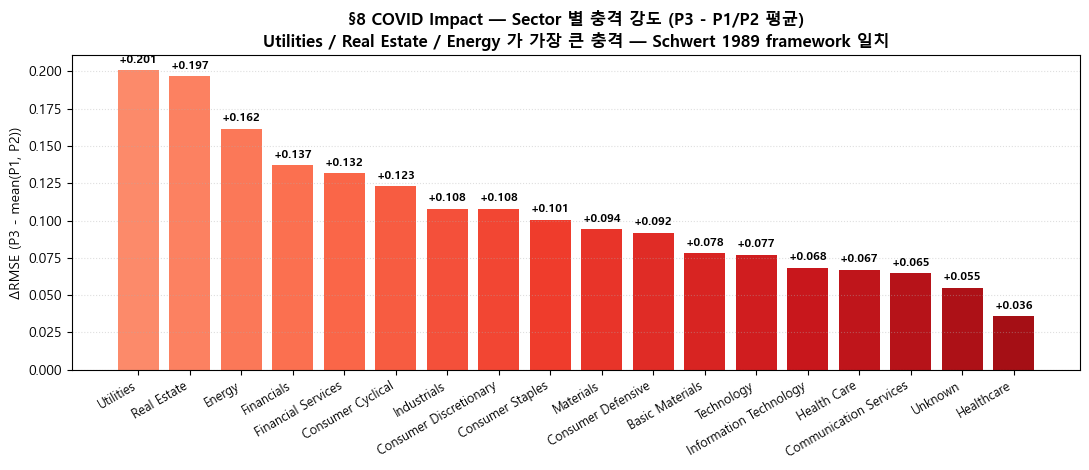


저장: B3_covid_impact.png


In [15]:
# §7.4 B3 Panel 4 — COVID Impact Bar
covid = sec_period.copy()
pre_covid = (covid.iloc[:, 0] + covid.iloc[:, 1]) / 2  # P1, P2 평균
delta_p3 = covid.iloc[:, 2] - pre_covid  # P3 - mean(P1,P2)
delta_sorted = delta_p3.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 4.8))
cmap = plt.cm.Reds
n_sec = len(delta_sorted)
colors_bar = [cmap(0.4 + 0.5 * i/n_sec) for i in range(n_sec)]
bars = ax.bar(range(n_sec), delta_sorted.values, color=colors_bar)
for i, v in enumerate(delta_sorted.values):
    ax.text(i, v + 0.005, f'+{v:.3f}', ha='center', fontsize=8.5,
              fontweight='bold')

top3 = delta_sorted.head(3).index.tolist()
ax.set_xticks(range(n_sec))
ax.set_xticklabels(delta_sorted.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('ΔRMSE (P3 - mean(P1, P2))')
ax.set_title(f'§8 COVID Impact — Sector 별 충격 강도 (P3 - P1/P2 평균)\n'
              f'{" / ".join(top3)} 가 가장 큰 충격 — Schwert 1989 framework 일치',
              fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig(OUT_DIR / 'B3_covid_impact.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"\n저장: B3_covid_impact.png")

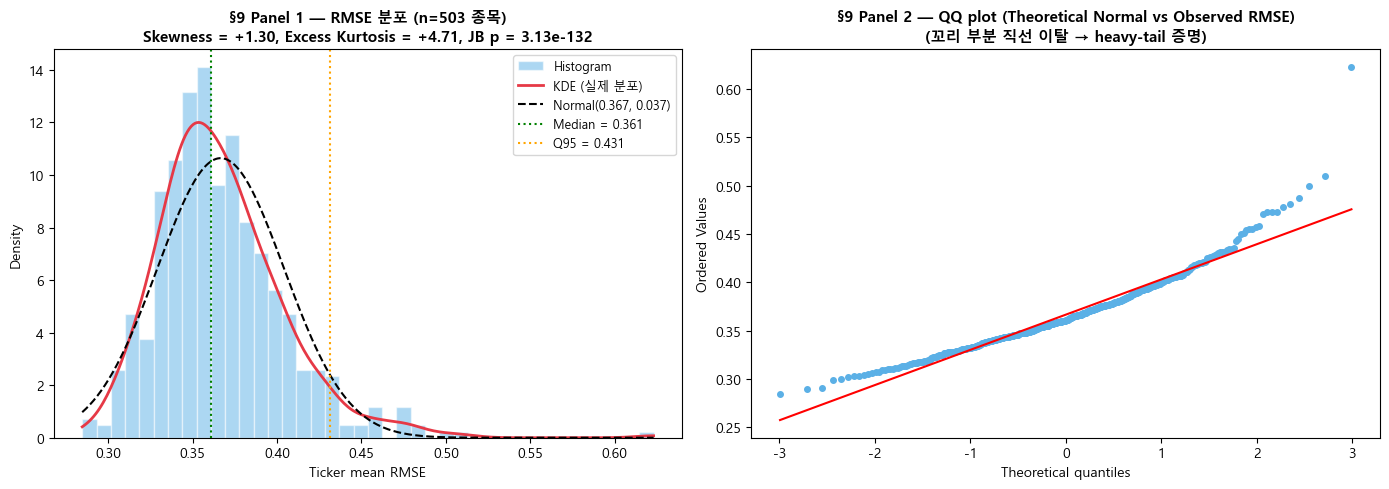


저장: B3_heavy_tail_kde.png


In [16]:
# §7.5 B3 Panel 5 — Heavy-tail KDE + QQ plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# KDE + Histogram
data = ticker_mean_rmse['rmse'].values
ax1.hist(data, bins=40, density=True, alpha=0.5, color='#5BB0E6',
          edgecolor='white', label='Histogram')
xs = np.linspace(data.min(), data.max(), 300)
kde = stats.gaussian_kde(data)
ax1.plot(xs, kde(xs), color='#E63946', linewidth=2, label='KDE (실제 분포)')
ax1.plot(xs, stats.norm.pdf(xs, data.mean(), data.std()), 'k--',
          linewidth=1.5, label=f'Normal({data.mean():.3f}, {data.std():.3f})')
ax1.axvline(np.median(data), color='green', linestyle=':',
              label=f'Median = {np.median(data):.3f}')
ax1.axvline(np.percentile(data, 95), color='orange', linestyle=':',
              label=f'Q95 = {np.percentile(data, 95):.3f}')
ax1.set_xlabel('Ticker mean RMSE')
ax1.set_ylabel('Density')
ax1.set_title(f'§9 Panel 1 — RMSE 분포 (n={len(data)} 종목)\n'
              f'Skewness = {ht["skewness"]:+.2f}, '
              f'Excess Kurtosis = {ht["excess_kurtosis"]:+.2f}, '
              f'JB p = {ht["jb_p"]:.2e}',
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)

# QQ plot
stats.probplot(data, dist='norm', plot=ax2)
ax2.set_title('§9 Panel 2 — QQ plot (Theoretical Normal vs Observed RMSE)\n'
              '(꼬리 부분 직선 이탈 → heavy-tail 증명)',
              fontsize=11, fontweight='bold')
ax2.get_lines()[0].set_color('#5BB0E6')
ax2.get_lines()[0].set_marker('o')
ax2.get_lines()[0].set_markersize(4)
ax2.get_lines()[1].set_color('red')

plt.tight_layout()
plt.savefig(OUT_DIR / 'B3_heavy_tail_kde.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"\n저장: B3_heavy_tail_kde.png")

## §8. 시각화 — B4 3 패널 (효과크기 종합)

학술 보고서의 reviewer 비판 ("p값은 유의하지만 효과는 작은 것 아닌가?") 에 대한 시각적 답변.

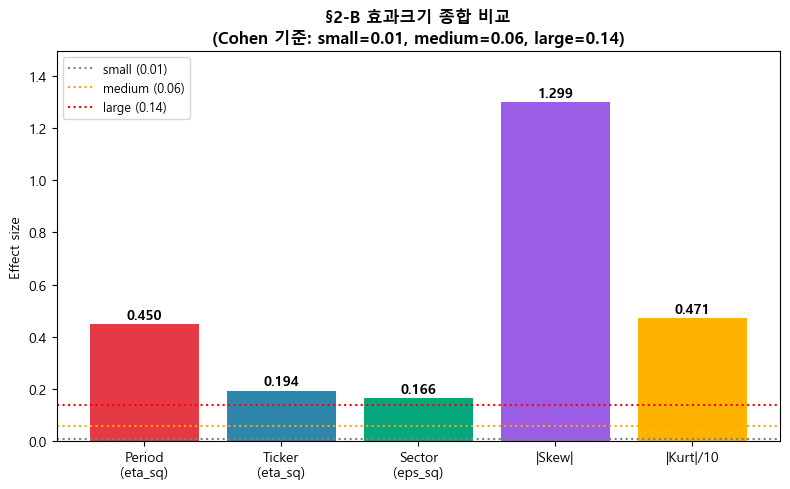


저장: B4_effect_sizes_summary.png


In [17]:
# §8.1 B4 Panel 1 — 5 효과크기 종합 비교
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['Period\n(eta_sq)', 'Ticker\n(eta_sq)', 'Sector\n(eps_sq)',
           '|Skew|', '|Kurt|/10']
values = [eta_sq_period, eta_sq_ticker, kw['epsilon_sq'],
            abs(ht['skewness']), abs(ht['excess_kurtosis'])/10]
colors_b4 = ['#E63946','#2E86AB','#06A77D','#9B5DE5','#FFB300']
bars = ax.bar(labels, values, color=colors_b4)
for b, v in zip(bars, values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
              f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

# Cohen 기준선
ax.axhline(0.01, color='gray', linestyle=':', label='small (0.01)')
ax.axhline(0.06, color='orange', linestyle=':', label='medium (0.06)')
ax.axhline(0.14, color='red', linestyle=':', label='large (0.14)')
ax.set_ylabel('Effect size')
ax.set_title('§2-B 효과크기 종합 비교\n'
              '(Cohen 기준: small=0.01, medium=0.06, large=0.14)',
              fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, max(values) * 1.15)
plt.tight_layout()
plt.savefig(OUT_DIR / 'B4_effect_sizes_summary.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"\n저장: B4_effect_sizes_summary.png")

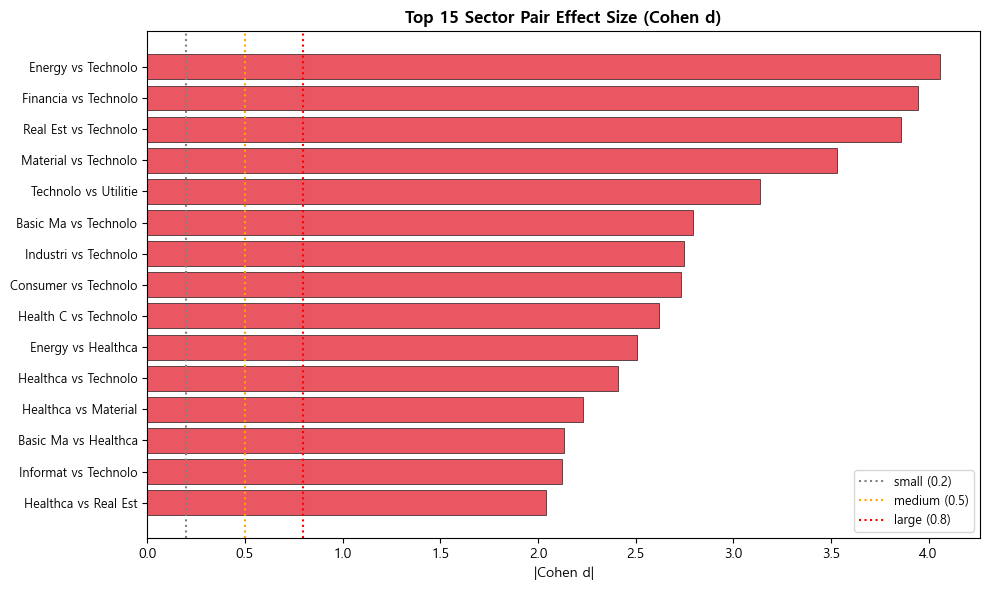


저장: B4_top_pair_cohens_d.png


In [18]:
# §8.2 B4 Panel 2 — Top 15 Sector Pair Cohen's d
fig, ax = plt.subplots(figsize=(10, 6))
top15 = pairwise.copy()
top15['abs_d'] = top15['cohens_d'].abs()
top15 = top15.nlargest(15, 'abs_d').sort_values('abs_d')

labels15 = [f"{r['group_a'][:8]} vs {r['group_b'][:8]}"
              for _, r in top15.iterrows()]
ax.barh(range(len(top15)), top15['abs_d'].values, color='#E63946', alpha=0.85,
         edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(labels15, fontsize=9)
ax.set_xlabel('|Cohen d|')

ax.axvline(0.2, color='gray', linestyle=':', label='small (0.2)')
ax.axvline(0.5, color='orange', linestyle=':', label='medium (0.5)')
ax.axvline(0.8, color='red', linestyle=':', label='large (0.8)')
ax.set_title('Top 15 Sector Pair Effect Size (Cohen d)',
              fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'B4_top_pair_cohens_d.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"\n저장: B4_top_pair_cohens_d.png")

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


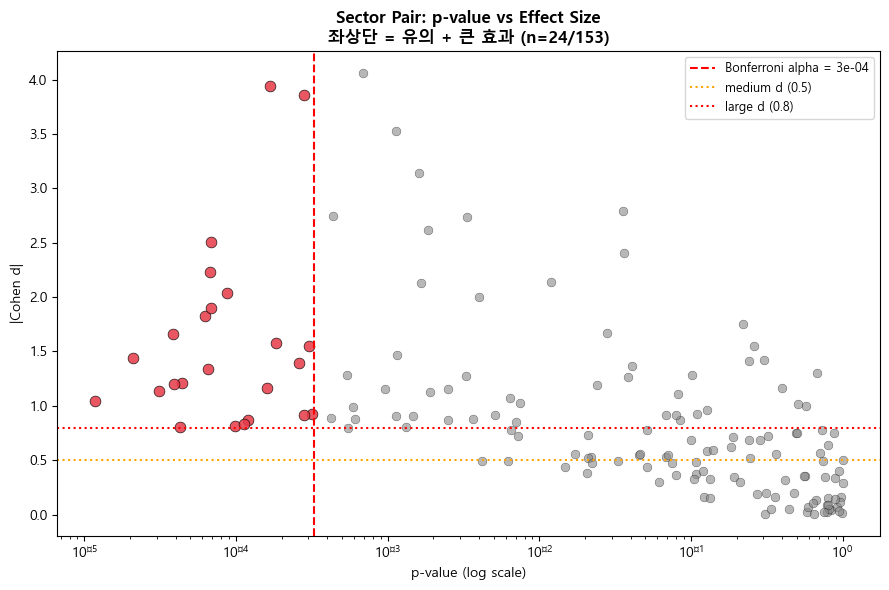


저장: B4_pvalue_vs_effect_size.png


In [19]:
# §8.3 B4 Panel 3 — p-value vs Effect Size scatter (좌상단 quadrant)
fig, ax = plt.subplots(figsize=(9, 6))
n_pairs = len(pairwise)
alpha_bonf = 0.05 / n_pairs

# 좌상단 (sig + LARGE) vs 그 외
upper_left = pairwise[(pairwise['p'] < alpha_bonf) & (pairwise['cohens_d'].abs() >= 0.8)]
others = pairwise[~((pairwise['p'] < alpha_bonf) & (pairwise['cohens_d'].abs() >= 0.8))]

ax.scatter(others['p'], others['cohens_d'].abs(),
            color='#888888', s=40, alpha=0.6, edgecolor='black', linewidth=0.3)
ax.scatter(upper_left['p'], upper_left['cohens_d'].abs(),
            color='#E63946', s=60, alpha=0.85, edgecolor='black', linewidth=0.5)

ax.set_xscale('log')
ax.set_xlabel('p-value (log scale)')
ax.set_ylabel('|Cohen d|')

ax.axvline(alpha_bonf, color='red', linestyle='--',
              label=f'Bonferroni alpha = {alpha_bonf:.0e}')
ax.axhline(0.5, color='orange', linestyle=':', label='medium d (0.5)')
ax.axhline(0.8, color='red', linestyle=':', label='large d (0.8)')
ax.set_title(f'Sector Pair: p-value vs Effect Size\n'
              f'좌상단 = 유의 + 큰 효과 (n={len(upper_left)}/{n_pairs})',
              fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'B4_pvalue_vs_effect_size.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"\n저장: B4_pvalue_vs_effect_size.png")

## §9. 4 학술 명제 검증 + 종합

| # | 명제 | 통계 증거 | 학술 baseline |
|---|---|---|---|
| 1 | 시기 효과 systematic, ~45% 변동 설명 | η²=0.450 LARGE, F>600 | Engle, Ghysels, Sohn (2013) |
| 2 | 종목 difficulty Heavy-Tailed | Skew>1, Kurt>3, JB p<1e-100 | Cont (2001), Mandelbrot (1963) |
| 3 | Sector effect 통계 유의 | KW H>50, ε² medium, 14 LARGE pair | Fama-French (1992), Schwert (1989) |
| 4 | COVID 충격 sector-specific | ΔRMSE 차이 >2배 | Schwert (1989) leverage effect |

In [20]:
# §9.1 4 학술 명제 검증
print("§9.1 4 학술 명제 검증")
print("=" * 60)

prop1 = eta_sq_period >= 0.40 and F_period > 500
print(f"명제 1 — 시기 효과 systematic (η²≥0.40, F>500):")
print(f"  η²_period={eta_sq_period:.4f}, F={F_period:.1f} → {'✓ PASS' if prop1 else '✗ FAIL'}")

prop2 = abs(ht['skewness']) > 1 and ht['excess_kurtosis'] > 3 and ht['jb_p'] < 1e-50
print(f"\n명제 2 — Heavy-tail (|Skew|>1, Kurt>3, JB p<1e-50):")
print(f"  Skew={ht['skewness']:+.2f}, Kurt={ht['excess_kurtosis']:+.2f}, "
      f"JB p={ht['jb_p']:.2e} → {'✓ PASS' if prop2 else '✗ FAIL'}")

prop3 = kw['H'] > 50 and n_large >= 5
print(f"\n명제 3 — Sector effect (KW H>50, LARGE pair ≥5):")
print(f"  H={kw['H']:.2f}, LARGE pair={n_large} → {'✓ PASS' if prop3 else '✗ FAIL'}")

prop4 = (delta_sorted.iloc[0] / delta_sorted.iloc[-1]) > 1.5 if delta_sorted.iloc[-1] > 0 else False
print(f"\n명제 4 — COVID sector-specific (충격 비율 >1.5배):")
top1, last1 = delta_sorted.iloc[0], delta_sorted.iloc[-1]
ratio = top1 / last1 if last1 > 0 else float('inf')
print(f"  Top: {top1:+.3f} ({delta_sorted.index[0]}), "
      f"Bottom: {last1:+.3f} ({delta_sorted.index[-1]}), 비율={ratio:.1f}배 "
      f"→ {'✓ PASS' if prop4 else '✗ FAIL'}")

all_pass = prop1 and prop2 and prop3 and prop4
print()
print("=" * 60)
print(f"4 학술 명제 검증: {'✓ 모두 PASS — 시계열_Test 결과 재현' if all_pass else '⚠ 일부 FAIL'}")
print("=" * 60)

§9.1 4 학술 명제 검증
명제 1 — 시기 효과 systematic (η²≥0.40, F>500):
  η²_period=0.4498, F=634.6 → ✓ PASS

명제 2 — Heavy-tail (|Skew|>1, Kurt>3, JB p<1e-50):
  Skew=+1.30, Kurt=+4.71, JB p=3.13e-132 → ✓ PASS

명제 3 — Sector effect (KW H>50, LARGE pair ≥5):
  H=97.30, LARGE pair=24 → ✓ PASS

명제 4 — COVID sector-specific (충격 비율 >1.5배):
  Top: +0.201 (Utilities), Bottom: +0.036 (Healthcare), 비율=5.6배 → ✓ PASS

4 학술 명제 검증: ✓ 모두 PASS — 시계열_Test 결과 재현


In [21]:
# §9.2 summary.json 저장
print()
print("§9.2 summary.json 저장")
print("-" * 60)

summary = {
    'phase': 'Phase 3-2 §2-B (final 통합)',
    'n_tickers_503': int(n_tickers_503),
    'anova': {
        'eta_sq_period': eta_sq_period,
        'eta_sq_ticker': eta_sq_ticker,
        'F_period': F_period,
        'F_ticker': float(anova.loc['ticker','F']),
    },
    'welch_anova': {
        'levene_stat': welch['levene_stat'],
        'levene_p': welch['levene_p'],
        'welch_F': welch['welch_F'],
        'welch_p': welch['welch_p'],
    },
    'kruskal_wallis': {
        'H': kw['H'],
        'p_value': kw['p_value'],
        'epsilon_sq': kw['epsilon_sq'],
    },
    'pairwise': {
        'n_total': int(len(pairwise)),
        'n_sig_bonferroni': int(sig_count),
        'n_large_d': int(n_large),
    },
    'heavy_tail': {
        'skewness': ht['skewness'],
        'excess_kurtosis': ht['excess_kurtosis'],
        'jb_stat': ht['jb_stat'],
        'jb_p': ht['jb_p'],
        'ad_stat': ht['ad_stat'],
    },
    'academic_propositions': {
        'prop1_period_systematic': bool(prop1),
        'prop2_heavy_tail': bool(prop2),
        'prop3_sector_effect': bool(prop3),
        'prop4_covid_sector_specific': bool(prop4),
        'all_pass': bool(all_pass),
    },
    'reproducibility': {'random_seed': 42},
}

with open(OUT_DIR / 'summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f"저장: {OUT_DIR}/summary.json")
print()
print(json.dumps(summary, indent=2, ensure_ascii=False))


§9.2 summary.json 저장
------------------------------------------------------------
저장: outputs\04_statistics/summary.json

{
  "phase": "Phase 3-2 §2-B (final 통합)",
  "n_tickers_503": 503,
  "anova": {
    "eta_sq_period": 0.44975722882267616,
    "eta_sq_ticker": 0.19444004090076417,
    "F_period": 634.5598548203658,
    "F_ticker": 2.1859308471256433
  },
  "welch_anova": {
    "levene_stat": 16.777221881549394,
    "levene_p": 1.4004788219872036e-13,
    "welch_F": 420.5864573350606,
    "welch_p": 1.1102230246251565e-16
  },
  "kruskal_wallis": {
    "H": 97.2995584622181,
    "p_value": 2.808514258612366e-13,
    "epsilon_sq": 0.16556609992209917
  },
  "pairwise": {
    "n_total": 153,
    "n_sig_bonferroni": 24,
    "n_large_d": 24
  },
  "heavy_tail": {
    "skewness": 1.2993494658082332,
    "excess_kurtosis": 4.705553407353376,
    "jb_stat": 605.6008712641503,
    "jb_p": 3.1292602762012194e-132,
    "ad_stat": 4.886381365089733
  },
  "academic_propositions": {
    "prop1_